## Markov Chain Monte Carlo (MCMC)
### 2026/03/05

Markov Chain Monte Carlo (MCMC) is a sampling method used to efficiently map out a probability distribution, weighted towards the greatest probability.
The Markov chain is formed by the following rules:

1. If $f(x') > f(x)$ : accept
2. If $f(x') < f(x)$ : accept with probabilty $\frac{f(x')}{f(x)}$

These rules effectively mean we:

1. Sample the high density regions
2. Sometimes sample the low density regions

In python we can use the package `emcee` to perform this. In this notebook I will test `emcee` against a polynomial function.

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters, Minimizer, create_params, report_fit
import emcee
import corner
import pandas

Lets define our underlying test data is a noisy sine wave. 
The task is to find the parameters that best fit this data. Since our test data resembles a sine wave, I will choose my model to be a sine function $y_{model} = a\mathrm{sin}(2\pi x/p)$, with two parameters a (amplitude), and p (period) - the test data is also this but with added noise.

For my application, the noisy test data is my experimental data, the model is my synthetic data.

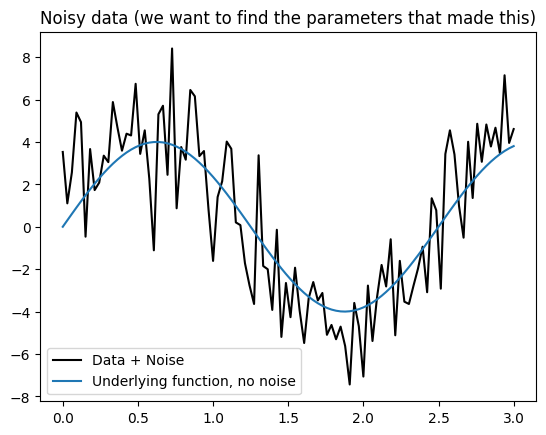

In [75]:
np.random.seed(0)

def testdata(x, a, p, noise = True):
    if noise:
        return a * np.sin(2*np.pi*x/p) + np.random.normal(size=len(x), scale=2)
    else:
        return a * np.sin(2*np.pi*x/p)

a = 4
p = 2.5
xdata = np.linspace(0, 3, 100)
ydata = testdata(xdata, a, p)
ydata_clean = testdata(xdata, a, p, noise=False)
plt.title("Noisy data (we want to find the parameters that made this)")
plt.plot(xdata, ydata, label="Data + Noise", color="black")
plt.plot(xdata, ydata_clean, label="Underlying function, no noise")
plt.legend()

I define my model (my synthetic data) as:

$$f(x,a,p) = a\ \mathrm{sin}(2 \pi x/p)$$

The fitting procedure I will use is a reduced chi-squared:

$$\chi^2 = \frac{1}{N-M} \Sigma^n_{n=0}\frac{(y_i - y_m(a,p))^2}{\sigma^2}$$

Note my noisy test data does not have a standard deviation $\sigma$ associated with it, though I could define one based on the local variance..

#### `LMFIT` Least-Squares (Levenberg-Marquardt)

In [60]:
def chi2(y, y_model, sigma=None):
    if sigma is None:
        sigma = np.ones_like(y)
    dof = len(y) - 2
    return np.sum((y - y_model)**2 / sigma**2) / dof

def objective(params, x, y):
    amp = params["amp"]
    period = params["period"]
    y_model = amp * np.sin(2*np.pi*x/period)
    return (y_model - ydata)

The objective function is formed of the possible $\chi^2$ values for my parameter space. It should have some minima or maxima since one set of parameters $a$ and $p$ should fit my noisy data the best. The objective function is effectively the probability distribution that we want to find using MCMC.

In [61]:
# params = Parameters()
# params.add("a", value = 3, min = 1, max = 6)
# params.add("p", value = 2, min = 1, max = 6)
params = create_params(amp=dict(value=3, min=1, max=6), period=dict(value=2, min=1, max=6))

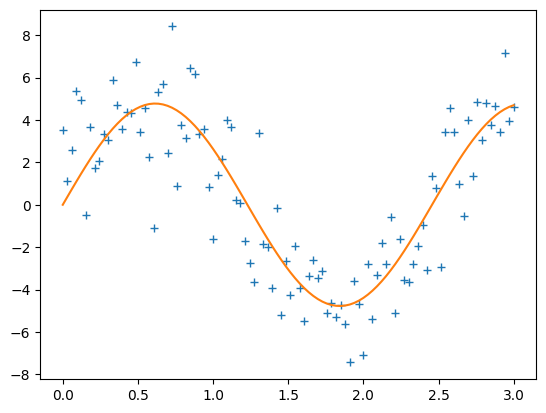

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 100
    # variables        = 2
    chi-square         = 369.874015
    reduced chi-square = 3.77422465
    Akaike info crit   = 134.799226
    Bayesian info crit = 140.009567
[[Variables]]
    amp:     4.77416478 +/- 0.27966907 (5.86%) (init = 3)
    period:  2.45685791 +/- 0.03155617 (1.28%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(amp, period) = +0.1093


In [62]:
leastsq = minimize(fcn=objective, params=params, args=(xdata, ydata))
# calculate final result
final = ydata + leastsq.residual

# try to plot results
try:
    import matplotlib.pyplot as plt
    plt.plot(xdata, ydata, '+')
    plt.plot(xdata, final)
    plt.show()
except ImportError:
    pass
report_fit(leastsq)

#### `LMFIT` + `emcee` Markov Chain Monte Carlo

In [71]:
minner = Minimizer(objective, params, fcn_args=(xdata, ydata))
mcmc_res = minner.emcee(steps=500, burn = 30)

# compute the fitted model from the best-fit parameters
best_a = mcmc_res.params['amp'].value
best_p = mcmc_res.params['period'].value
fitted_model = best_a * np.sin(2*np.pi*xdata/best_p)

# show the minimization result
report_fit(mcmc_res)

The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 10;
tau: [21.25625416 20.13467975]
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 50000
    # data points      = 100
    # variables        = 2
    chi-square         = 369.879894
    reduced chi-square = 3.77428463
    Akaike info crit   = 134.800816
    Bayesian info crit = 140.011156
[[Variables]]
    amp:     4.76349195 +/- 0.14841336 (3.12%) (init = 4.777028)
    period:  2.45704116 +/- 0.01594030 (0.65%) (init = 2.456314)


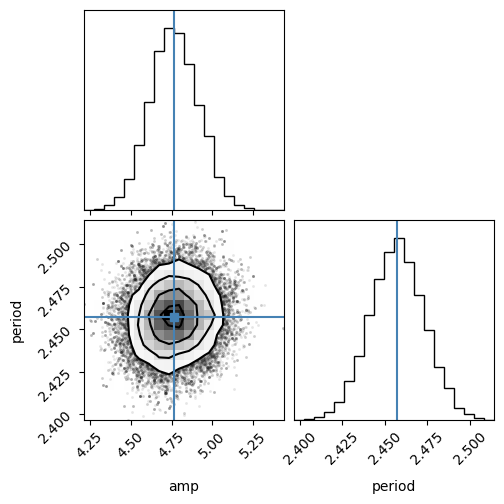

In [72]:
emcee_plot = corner.corner(mcmc_res.flatchain, labels=mcmc_res.var_names,
                           truths=list(mcmc_res.params.valuesdict().values()))


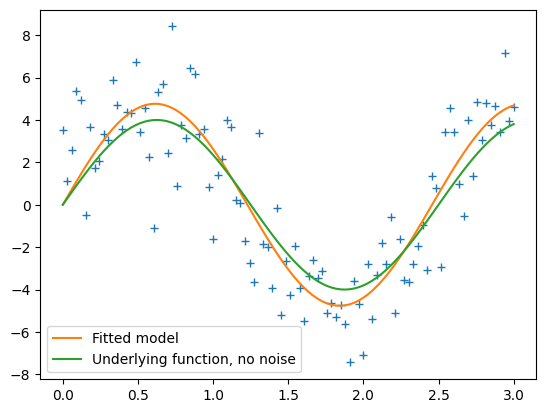

In [77]:
# Plot
y_model = best_a * np.sin(2*np.pi*xdata/best_p)
plt.plot(xdata, ydata, '+')
plt.plot(xdata, y_model, label="Fitted model")
plt.plot(xdata, ydata_clean, label="Underlying function, no noise")
plt.legend()
plt.show()

In [74]:
highest_prob = np.argmax(mcmc_res.lnprob)
hp_loc = np.unravel_index(highest_prob, mcmc_res.lnprob.shape)
mle_soln = mcmc_res.chain[hp_loc]
for i, par in enumerate(params):
    params[par].value = mle_soln[i]

print('\nMaximum Likelihood Estimation from emcee       ')
print('-------------------------------------------------')
print('Parameter  MLE Value   Median Value   Uncertainty')
fmt = '  {:5s}  {:11.5f} {:11.5f}   {:11.5f}'.format
for name, param in params.items():
    print(fmt(name, param.value, mcmc_res.params[name].value,
              mcmc_res.params[name].stderr))



Maximum Likelihood Estimation from emcee       
-------------------------------------------------
Parameter  MLE Value   Median Value   Uncertainty
  amp        4.77380     4.76349       0.14841
  period      2.45689     2.45704       0.01594
